# Coursework Set Week 5

    
### <font color='hotpink'> Geniet van de memes! Groetjes Noa</font>

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Noa Krosse
* Username: nwmkrosse
* Student number: S6371582
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

4e+40
6.674299999999999e-20


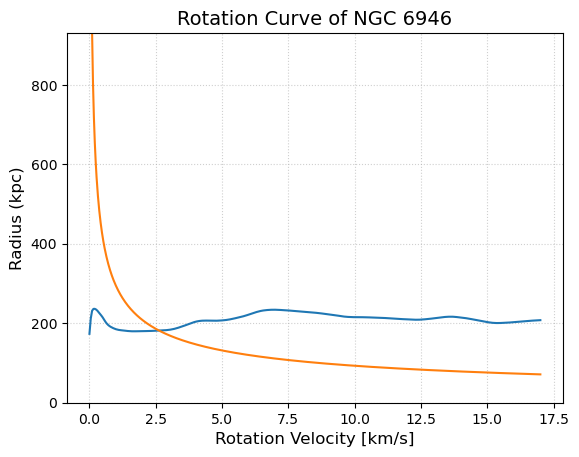

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

M_ngc6946=2e10 * 2e30
giga_G = G/1e9
print(M_ngc6946)
print(giga_G)

(radi, rot_v)=np.array(np.loadtxt("rotcur.dat", unpack=True))

big_radii = np.linspace(np.min(radi)+0000.1, np.max(radi), 1000) # to get radii that are not 0, otherwise the code does not work.

keplerian_curve=[]

for r in big_radii:
    v=float(np.sqrt(giga_G*M_ngc6946/(r*3.086e16)))
    keplerian_curve.append(v)
   
np.savetxt('keplerian_curve.txt', keplerian_curve, delimiter=', ') 

keppie=np.array(np.loadtxt("keplerian_curve.txt", unpack=True))
keppie_max=np.max(keppie)

plt.plot(radi, rot_v)
plt.plot(big_radii, keppie)
plt.ylim(0, keppie_max)
plt.title('Rotation Curve of NGC 6946', fontsize=14)
plt.xlabel('Rotation Velocity [km/s]', fontsize=12)
plt.ylabel('Radius (kpc)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

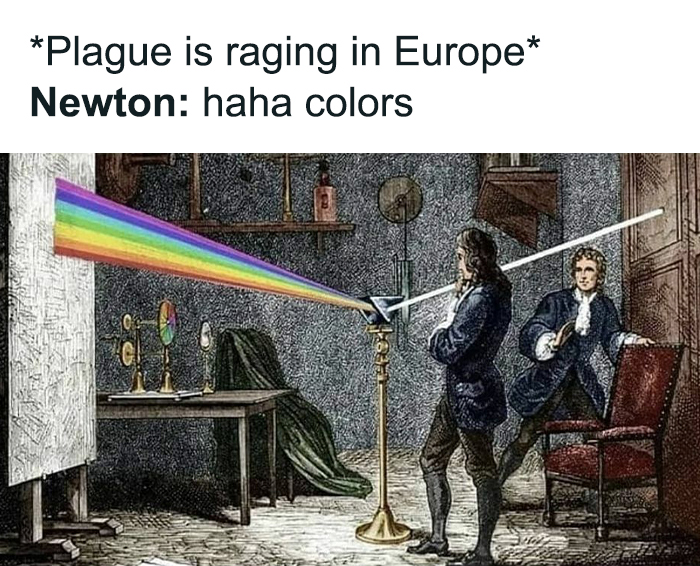

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

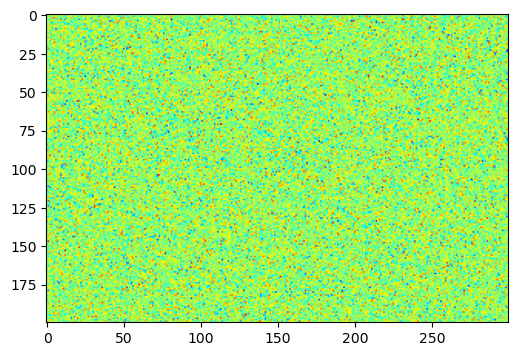

Slice Mean: -0.011813004712692388
Slice Standard Deviation: 1.012291813738039


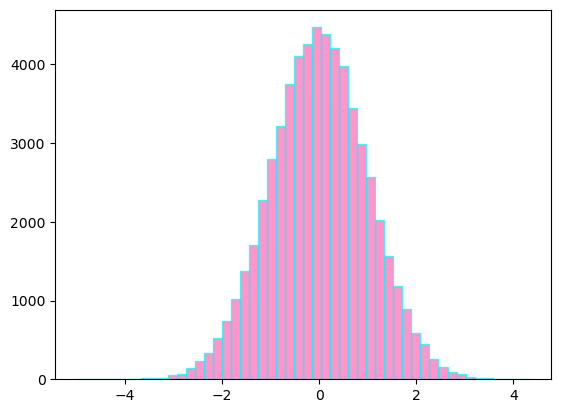

In [4]:
import numpy as np
import matplotlib.pyplot as plt


image_data = np.random.normal(loc=0.0, scale=1.0, size=(200, 300))

plt.figure(figsize=(8, 4))
plt.imshow(image_data, cmap='jet')
plt.show()


image_slice = image_data[100:130, 100:130]
slice_mean = np.mean(image_slice)
slice_std = np.std(image_slice)

print(f"Slice Mean: {slice_mean}")
print(f"Slice Standard Deviation: {slice_std}")

plt.figure()
plt.hist(image_data.ravel(), bins=50, color='hotpink', edgecolor='aqua', alpha=0.7)
plt.show()

## Answers to the assignment questions
#### Are this mean and standard deviation what you expected?
Yeah, this is pretty much what I expected. Since I set up the whole big array to have a mean of 0 and a standard deviation of 1.0, any slice we take from it should have almost the exact same stats. A 30x30 slice gives us 900 pixels, which is a big enough sample size to get really close to the original 0 and 1.0, even if it's a tiny bit off just because of random chance.

#### What distribution should you recognise?
a Normal distribution (also known as a Gaussian distribution). 

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

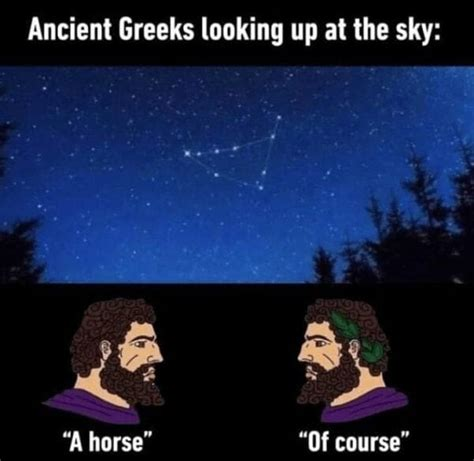

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area: 18.84955592153876
Perimeter: 15.865437575563961
Center: (0, 0), Axes: 3 and 2, Angle: 0


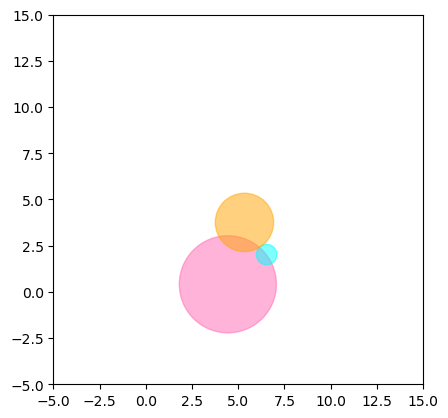

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)  
        XY = (xc, yc)                  
        angle_mpl = position_angle     
        height = 2.0*semi_major        
        width  = 2.0*semi_minor        
        super().__init__(XY, width, height, angle=angle_mpl, **args)
        
        #variables for new methods
        self.xc = xc
        self.yc = yc
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.position_angle = position_angle

    
    def area(self):
        return np.pi * self.semi_major * self.semi_minor

    def perimeter(self):
        a = self.semi_major
        b = self.semi_minor
        return np.pi * (3 * (a + b) - np.sqrt((3 * a + b) * (a + 3 * b)))

    def __str__(self):
        return f"Center: ({self.xc}, {self.yc}), Axes: {self.semi_major} and {self.semi_minor}, Angle: {self.position_angle}"


class circle(AstroEllipse):
    def __init__(self, center, radius, **args):
        xc = center[0]
        yc = center[1]
        AstroEllipse.__init__(self, xc, yc, radius, radius, 0, **args)


#example
my_ellipse = AstroEllipse(0, 0, 3, 2, 0)

print("Area:", my_ellipse.area())
print("Perimeter:", my_ellipse.perimeter())
print(my_ellipse)

fig = plt.figure()
ax = fig.add_subplot(111)

c1 = circle((np.random.rand()*10, np.random.rand()*10), np.random.rand()*5, color='hotpink', alpha=0.5)
c2 = circle((np.random.rand()*10, np.random.rand()*10), np.random.rand()*5, color='aqua', alpha=0.5)
c3 = circle((np.random.rand()*10, np.random.rand()*10), np.random.rand()*5, color='orange', alpha=0.5)

ax.add_patch(c1)
ax.add_patch(c2)
ax.add_patch(c3)
ax.set_aspect('equal', adjustable='box') #note to self: to make circles
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)

plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

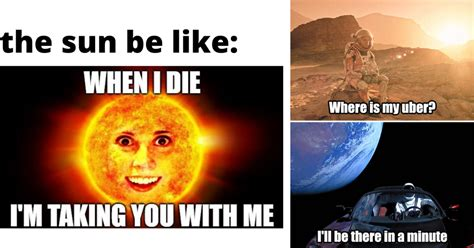

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

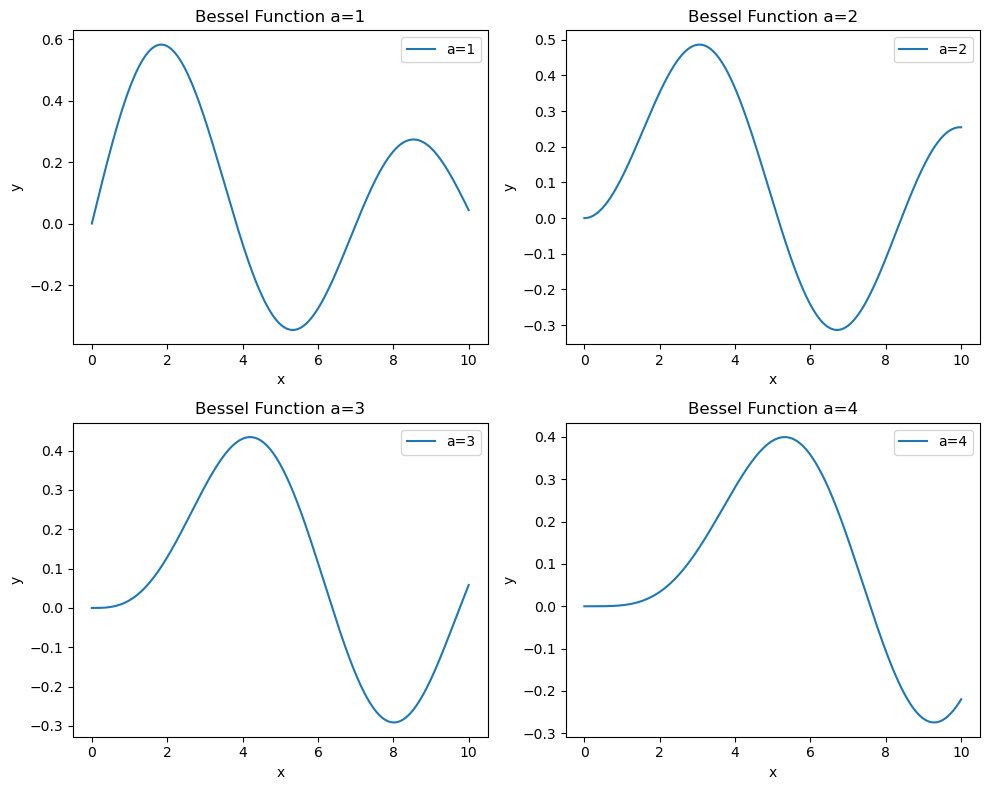

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

x = np.linspace(0, 10, 1000)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axes_list = axs.flatten()
a_values = [1, 2, 3, 4]

for i in range(4):
    a = a_values[i]         
    ax = axes_list[i]       
    y = jv(a, x)
    
    ax.plot(x, y, label=f'a={a}')
    ax.set_title(f'Bessel Function a={a}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()


fig.tight_layout()

fig.savefig('bessel.png', transparent=True)

plt.show()


# Photo of bessel that i downloaded
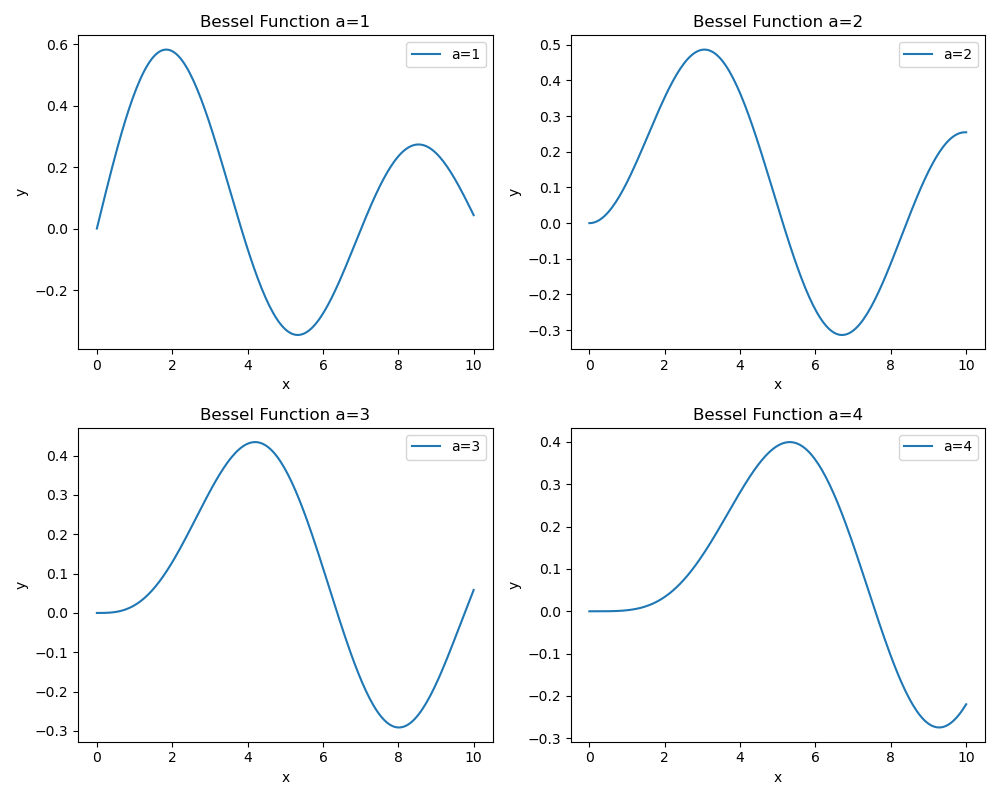

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

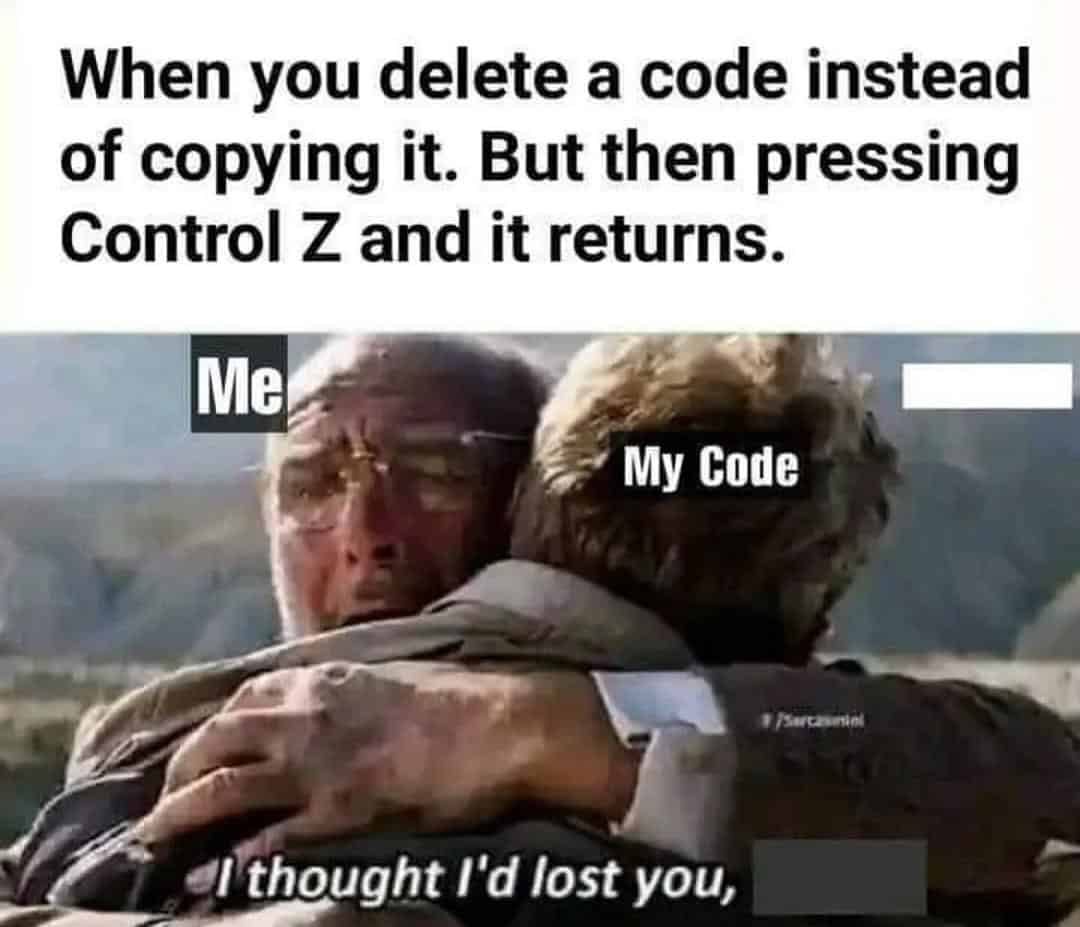


### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

d:[18.49, 35.48, 35.48, 11.34, 7.12, 9.82, 23.66, 44, 66.7, 52.4, 55, 25.6, 26.19]
v:[2094.75, 2320.87, 1224.9, 872.13, 432.2, 751, 1410, 2700, 5292, 2550, 5253, 2419, 2158]
[0.3, 2.2, 3.0, 1.2, 0.4, 0.3, 2.3, 4.0, 5.3, 5.2, 6.1, 3.2, 2.8]
[100, 120, 80, 80, 70, 75, 70, 110, 120, 100, 150, 110, 110]
66.7


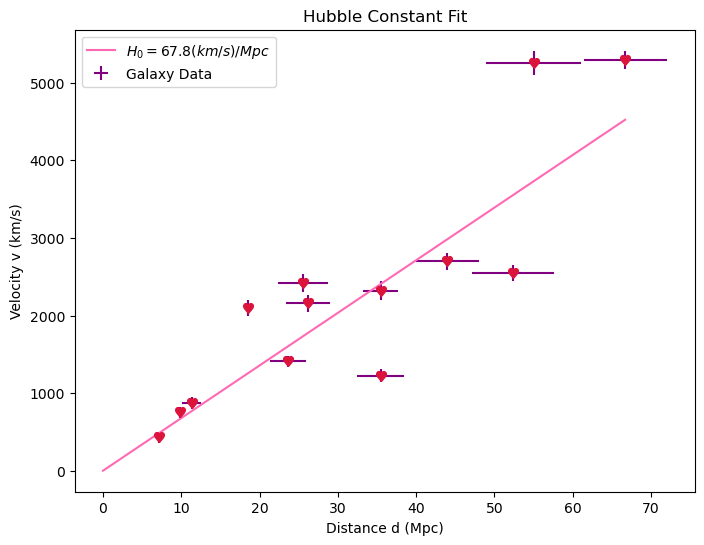

In [10]:
import matplotlib.pyplot as plt

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]


d = data[0::4]       
v = data[1::4]       
error_d = data[2::4] 
error_v = data[3::4] 

print(f"d:{d}")
print(f"v:{v}")
print(error_d)
print(error_v)


fig, ax = plt.subplots(figsize=(8, 6))


ax.errorbar(d, v, xerr=error_d, yerr=error_v, fmt='none', ecolor='purple', label='Galaxy Data')
ax.scatter(d, v, marker='$\u2665$', color='crimson', s=50, zorder=3)     #I did use google (ai) for the hearts, but they cute are right! 

H_0 = 67.8
max_d = max(d) 

print(max_d)

d_line = [0, max_d]
v_line = [0, H_0 * max_d] 

ax.plot(d_line, v_line, color='hotpink', label=r'$H_0 = 67.8(km/s)/Mpc$')

ax.set_xlabel('Distance d (Mpc)')
ax.set_ylabel('Velocity v (km/s)')
ax.set_title('Hubble Constant Fit')

ax.legend()

plt.show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

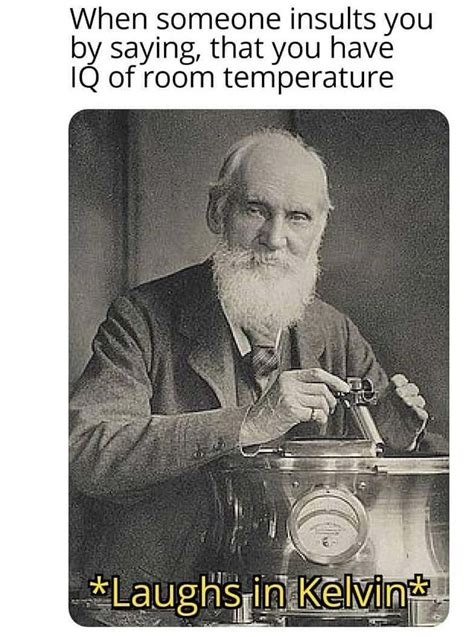

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0


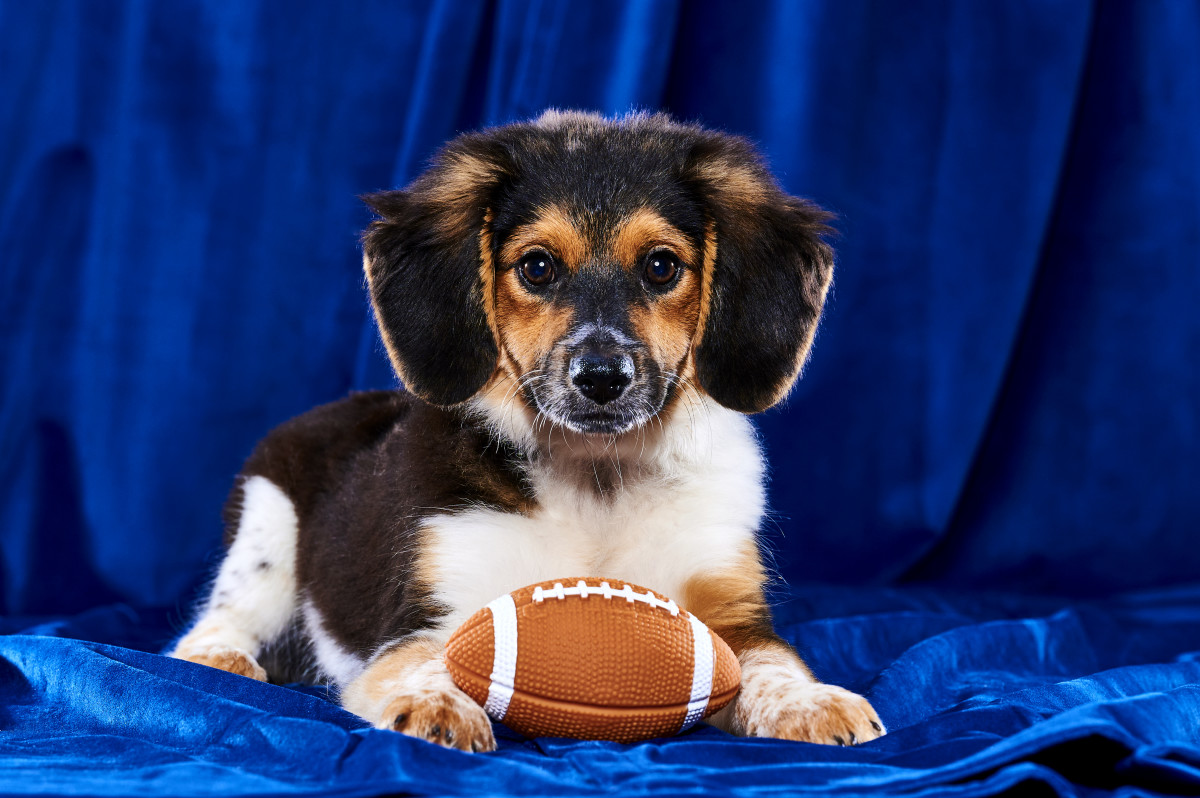
